<a href="https://colab.research.google.com/github/pichate-k/advance-ML/blob/main/text_mining%20/student/Adv_ML_Text_mining_01_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# install and import libraries
# ============================================================

!pip install pandas scikit-learn matplotlib seaborn beautifulsoup4 -q

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

print("✅ Environment is ready.")

✅ Environment is ready.


In [2]:
# ============================================================
# Upload customer_feedback_sentiment.csv
# ============================================================

from google.colab import files

uploaded = files.upload()

DATA_FILE = "customer_feedback_sentiment.csv"

if DATA_FILE not in uploaded:
    raise FileNotFoundError(
        f"ไม่พบไฟล์ '{DATA_FILE}' "
        "กรุณาเลือก upload ไฟล์ customer_feedback_sentiment.csv"
    )

df = pd.read_csv(DATA_FILE)

print("✅ Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())

Saving customer_feedback_sentiment.csv to customer_feedback_sentiment.csv
✅ Dataset loaded successfully.
Dataset shape: (800, 4)


,review_id,review_text,sentiment,source
0,1,ข้างซองบุหรี่เขียนยาดองศพตัวเท่าควาย เสือกขายไ...,negative,wisesight_sentiment
1,2,ไช้ครับป๋าเขาเขาควันเยอะบอกอัตราย,negative,wisesight_sentiment
2,3,โอเคค่ะ ขอบคุณนะคะ,positive,wisesight_sentiment
3,4,อย่าโชว์เหนือ เสือไม่ชอบ,negative,wisesight_sentiment
4,5,ลดน้ำหนักอยู่,positive,wisesight_sentiment


In [3]:
# ============================================================
# Validate dataset columns
# ============================================================

required_columns = {
    "review_id",
    "review_text",
    "sentiment",
    "source"
}

missing_columns = required_columns - set(df.columns)

assert not missing_columns, (
    f"Dataset ไม่มีคอลัมน์ที่จำเป็น: {missing_columns}"
)

assert df["review_text"].notna().any(), (
    "คอลัมน์ review_text ไม่มีข้อมูล"
)

assert df["sentiment"].nunique() >= 2, (
    "คอลัมน์ sentiment ต้องมีอย่างน้อย 2 classes"
)

print("✅ Dataset validation passed.")
print("Columns:", df.columns.tolist())

✅ Dataset validation passed.
Columns: ['review_id', 'review_text', 'sentiment', 'source']


# Part 1: Data Exploration

ในส่วนนี้ให้นักศึกษาสำรวจคุณภาพของ dataset ก่อนสร้างโมเดล

สิ่งที่ต้องตรวจสอบ:

- จำนวนแถวและคอลัมน์
- ชนิดข้อมูลในแต่ละคอลัมน์
- Missing values
- Duplicate rows
- จำนวนข้อมูลในแต่ละ sentiment class

In [4]:
# ============================================================
# TASK 1: Data Exploration
# ============================================================

print("Dataset shape:", df.shape)

print("\n--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
display(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())

print("\n--- Sentiment Distribution ---")
display(df["sentiment"].value_counts())

print("\n--- Random Samples ---")
display(df.sample(5, random_state=RANDOM_STATE))

Dataset shape: (800, 4)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    800 non-null    int64 
 1   review_text  800 non-null    object
 2   sentiment    800 non-null    object
 3   source       800 non-null    object
dtypes: int64(1), object(3)
memory usage: 25.1+ KB

--- Missing Values ---


,0
review_id,0
review_text,0
sentiment,0
source,0



--- Duplicate Rows ---
0

--- Sentiment Distribution ---


,count
sentiment,
negative,400
positive,400



--- Random Samples ---


,review_id,review_text,sentiment,source
696,697,นี่เลยเหมาะ,positive,wisesight_sentiment
667,668,กลับมาค่อยไปกินกัน,positive,wisesight_sentiment
63,64,ป่ะ กินกัน,positive,wisesight_sentiment
533,534,ในที่สุดก็ได้เงินคืนจากลาซาด้า แต่ได้เป็นวอลเล...,negative,wisesight_sentiment
66,67,เลิกม้วนได้เพราะไฟฟ้าเลย,positive,wisesight_sentiment


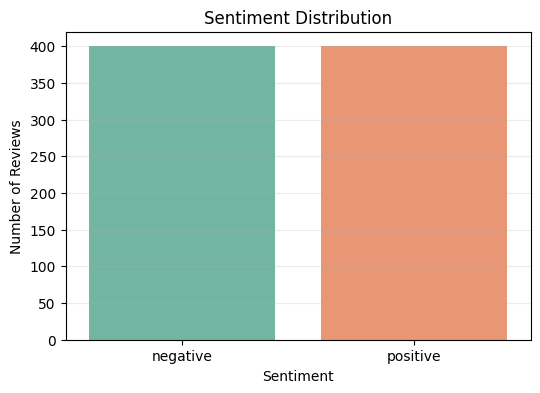

In [5]:
# ============================================================
# TASK 1.1: Visualize Sentiment Distribution
# ============================================================

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="sentiment",
    hue="sentiment",
    legend=False,
    palette="Set2",
    order=["negative", "positive"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.grid(axis="y", alpha=0.25)

plt.show()

## ANSWER: Task 1 — Data Exploration

1. Dataset มีจำนวนทั้งหมด: `....................` แถว และ `....................` คอลัมน์

2. Missing values:
   - พบ / ไม่พบ
   - รายละเอียด: `................................................................`

3. Duplicate rows:
   - มีจำนวน `....................` แถว

4. จำนวนข้อมูลแต่ละ class:
   - Negative: `....................`
   - Positive: `....................`

5. Dataset มีความสมดุลระหว่าง positive และ negative หรือไม่:

   `................................................................`

6. จากตัวอย่างข้อความ พบ noise หรือปัญหาของข้อมูลใดบ้าง:

   `................................................................`

# Part 2: Text Cleaning

เป้าหมายของขั้นตอนนี้คือสร้างคอลัมน์ `clean_text`
เพื่อนำไปใช้สร้าง TF-IDF features

ให้สังเกตความแตกต่างระหว่าง `review_text` และ `clean_text`

การทำความสะอาดในแลปนี้ประกอบด้วย:

- แปลงข้อความเป็นตัวพิมพ์เล็ก
- ลบ HTML tags
- ลบ URLs
- ลบ email
- ลบอักขระพิเศษบางส่วน
- ลดช่องว่างซ้ำ

In [6]:
# ============================================================
# Basic dataset cleaning
# ============================================================

df = df.dropna(subset=["review_text", "sentiment"]).copy()

df = df.drop_duplicates(subset=["review_text"]).copy()

df["review_text"] = df["review_text"].astype(str)

df["sentiment"] = (
    df["sentiment"]
    .astype(str)
    .str.strip()
    .str.lower()
)

valid_labels = {"positive", "negative"}

df = df[
    df["sentiment"].isin(valid_labels)
].copy()

print("✅ Shape after basic cleaning:", df.shape)

display(df["sentiment"].value_counts())

✅ Shape after basic cleaning: (800, 4)


,count
sentiment,
negative,400
positive,400


In [7]:
# ============================================================
# TASK 2: Text Cleaning
# ============================================================

def clean_text(text):
    text = str(text).lower()

    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text(" ")

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Remove emails
    text = re.sub(r"\S+@\S+", " ", text)

    # TODO 1:
    # ลบอักขระพิเศษ โดยเก็บเฉพาะภาษาไทย ภาษาอังกฤษ และช่องว่าง
    text = re.sub(r"[^a-zA-Zก-๙\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [8]:
# ============================================================
# TASK 2.1: Apply Text Cleaning
# ============================================================

df["clean_text"] = df["review_text"].apply(clean_text)

assert "clean_text" in df.columns, (
    "ไม่พบคอลัมน์ clean_text"
)

assert df["clean_text"].str.len().gt(0).any(), (
    "clean_text ว่างทั้งหมด กรุณาตรวจฟังก์ชัน clean_text()"
)

print("✅ Text cleaning completed.")

display(
    df[
        [
            "review_text",
            "clean_text",
            "sentiment"
        ]
    ].head(10)
)

✅ Text cleaning completed.


,review_text,clean_text,sentiment
0,ข้างซองบุหรี่เขียนยาดองศพตัวเท่าควาย เสือกขายไ...,ข้างซองบุหรี่เขียนยาดองศพตัวเท่าควาย เสือกขายไ...,negative
1,ไช้ครับป๋าเขาเขาควันเยอะบอกอัตราย,ไช้ครับป๋าเขาเขาควันเยอะบอกอัตราย,negative
2,โอเคค่ะ ขอบคุณนะคะ,โอเคค่ะ ขอบคุณนะคะ,positive
3,อย่าโชว์เหนือ เสือไม่ชอบ,อย่าโชว์เหนือ เสือไม่ชอบ,negative
4,ลดน้ำหนักอยู่,ลดน้ำหนักอยู่,positive
5,ขี้แตกด้วยมึง กินลีโอเปนงี้ตล่อดด 555,ขี้แตกด้วยมึง กินลีโอเปนงี้ตล่อดด,negative
6,ผิวบอบบางยิ่งต้องดูแลเป็นพิเศษ… ใหม่! กันแดดสู...,ผิวบอบบางยิ่งต้องดูแลเป็นพิเศษ ใหม่ กันแดดสูตร...,positive
7,รถก็มีข้อผิดพลาดด้วยกันทุกค่าย... แต่ดูแลลูกค้...,รถก็มีข้อผิดพลาดด้วยกันทุกค่าย แต่ดูแลลูกค้าอย...,negative
8,๕๕๕๕๕ เราแค่ไปกินบาบีก้อนก็คีบอุด้งหล่น น้ำกระ...,๕๕๕๕๕ เราแค่ไปกินบาบีก้อนก็คีบอุด้งหล่น น้ำกระ...,negative
9,สำหรับงานวันนี้ 5555555555555555 ดื่มหรืออาบคร...,สำหรับงานวันนี้ ดื่มหรืออาบครับโทษที ขัดใจที่ต...,negative


## ANSWER: Task 2 — Text Cleaning

เลือกดูข้อความอย่างน้อย 3 ตัวอย่าง แล้วตอบคำถามต่อไปนี้

1. ขั้นตอน cleaning ลบหรือเปลี่ยนแปลงข้อมูลประเภทใดบ้าง

   `................................................................`

2. ตัวอย่างข้อความก่อน cleaning:

   `................................................................`

3. ตัวอย่างข้อความหลัง cleaning:

   `................................................................`

4. การลบ URL, HTML และอักขระพิเศษมีประโยชน์อย่างไรต่อโมเดล:

   `................................................................`

5. เหตุใดคำว่า `ไม่`, `ไม่ได้`, `not`, `never` จึงไม่ควรถูกลบทั้งหมด:

   `................................................................`

# Part 3: Train/Test Split

เราจะแบ่งข้อมูลเป็น:

- Training set: 80%
- Test set: 20%

Training set ใช้สำหรับฝึกโมเดล  
Test set ใช้สำหรับประเมินโมเดลกับข้อความที่โมเดลไม่เคยเห็นมาก่อน

ใช้ `stratify=y` เพื่อรักษาสัดส่วน positive และ negative
ให้ใกล้เคียงกันทั้งในชุด train และ test

In [9]:
# ============================================================
# TASK 3: Train/Test Split
# ============================================================

X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("\nTrain label distribution:")
display(y_train.value_counts(normalize=True).round(3))

print("\nTest label distribution:")
display(y_test.value_counts(normalize=True).round(3))

Train size: 640
Test size: 160

Train label distribution:


,proportion
sentiment,
negative,0.5
positive,0.5



Test label distribution:


,proportion
sentiment,
positive,0.5
negative,0.5


## ANSWER: Task 3 — Train/Test Split

1. จำนวนข้อมูล Train: `....................`

2. จำนวนข้อมูล Test: `....................`

3. เหตุใดจึงต้องแบ่งข้อมูลเป็น Train และ Test:

   `................................................................`

4. `stratify=y` มีประโยชน์อย่างไร:

   `................................................................`

5. เหตุใดจึงไม่ควร fit TF-IDF Vectorizer จากข้อมูลทั้งหมดก่อนแบ่ง Train/Test:

   `................................................................`

# Part 4: Text Classification

ในส่วนนี้จะสร้างโมเดลแบบ Pipeline:

```text
Clean Text
    ↓
TF-IDF Vectorizer
    ↓
Logistic Regression
    ↓
Predicted Sentiment
```

ให้นักศึกษาทดลองอย่างน้อย 2 configurations:

| Experiment | ngram_range | min_df |
|---|---|---:|
| Experiment 1 | `(1, 1)` | `2` |
| Experiment 2 | `(1, 2)` | `2` |

- `(1, 1)` หมายถึง unigram เช่น `ดี`, `แย่`, `ช้า`
- `(1, 2)` หมายถึง unigram และ bigram เช่น `ไม่ ดี`, `ส่ง ช้า`

In [11]:
# ============================================================
# Helper function for training and evaluation
# ============================================================

def train_and_evaluate_model(
    X_train,
    X_test,
    y_train,
    y_test,
    ngram_range=(1, 1),
    min_df=2
):
    model = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=ngram_range,
                min_df=min_df,
                max_df=0.90
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    tfidf = model.named_steps["tfidf"]

    results = {
        "model": model,
        "predictions": y_pred,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_negative": report["negative"]["f1-score"],
        "f1_positive": report["positive"]["f1-score"],
        "vocabulary_size": len(tfidf.get_feature_names_out())
    }

    return results

In [12]:
# ============================================================
# TASK 4.1: Experiment 1 - Unigram
# ============================================================

result_unigram = train_and_evaluate_model(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    ngram_range=(1, 1),
    min_df=2
)

print("✅ Experiment 1 completed.")
print("Accuracy:", round(result_unigram["accuracy"], 4))
print("F1-score (negative):", round(result_unigram["f1_negative"], 4))
print("F1-score (positive):", round(result_unigram["f1_positive"], 4))
print("Vocabulary size:", result_unigram["vocabulary_size"])

✅ Experiment 1 completed.
Accuracy: 0.7063
F1-score (negative): 0.7006
F1-score (positive): 0.7117
Vocabulary size: 862


In [13]:
# ============================================================
# TASK 4.2: Experiment 2 - Unigram + Bigram
# ============================================================

result_bigram = train_and_evaluate_model(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    ngram_range=(1, 2),
    min_df=2
)

print("✅ Experiment 2 completed.")
print("Accuracy:", round(result_bigram["accuracy"], 4))
print("F1-score (negative):", round(result_bigram["f1_negative"], 4))
print("F1-score (positive):", round(result_bigram["f1_positive"], 4))
print("Vocabulary size:", result_bigram["vocabulary_size"])

✅ Experiment 2 completed.
Accuracy: 0.7125
F1-score (negative): 0.7089
F1-score (positive): 0.716
Vocabulary size: 1045


In [14]:
# ============================================================
# TASK 4.3: Compare Experiments
# ============================================================

comparison_df = pd.DataFrame([
    {
        "Experiment": "Unigram (1,1)",
        "Vocabulary Size": result_unigram["vocabulary_size"],
        "Accuracy": result_unigram["accuracy"],
        "F1 Negative": result_unigram["f1_negative"],
        "F1 Positive": result_unigram["f1_positive"]
    },
    {
        "Experiment": "Unigram + Bigram (1,2)",
        "Vocabulary Size": result_bigram["vocabulary_size"],
        "Accuracy": result_bigram["accuracy"],
        "F1 Negative": result_bigram["f1_negative"],
        "F1 Positive": result_bigram["f1_positive"]
    }
])

display(
    comparison_df.style.format({
        "Accuracy": "{:.4f}",
        "F1 Negative": "{:.4f}",
        "F1 Positive": "{:.4f}"
    })
)

,Experiment,Vocabulary Size,Accuracy,F1 Negative,F1 Positive
0,"Unigram (1,1)",862,0.7063,0.7006,0.7117
1,"Unigram + Bigram (1,2)",1045,0.7125,0.7089,0.7160


## ANSWER: Task 4 — Model Comparison

| Experiment | Vocabulary Size | Accuracy | F1 Negative | F1 Positive |
|---|---:|---:|---:|---:|
| Unigram | ... | ... | ... | ... |
| Unigram + Bigram | ... | ... | ... | ... |

1. Configuration ใดให้ Accuracy สูงกว่า:

   `................................................................`

2. Configuration ใดให้ F1-score ของ Negative สูงกว่า:

   `................................................................`

3. การใช้ Bigram ส่งผลต่อ Vocabulary Size อย่างไร:

   `................................................................`

4. เพราะเหตุใด Bigram อาจช่วยให้โมเดลเข้าใจ sentiment ดีขึ้น:

   `................................................................`

5. โมเดลใดควรเลือกเป็น Best Model และเพราะเหตุใด:

   `................................................................`

# Model Evaluation

In [15]:
# ============================================================
# TASK 5: Select Best Model
# ============================================================

# TODO 2:
# เปลี่ยนค่า BEST_RESULT เป็น result_unigram หากนักศึกษาพบว่า
# Unigram เป็นโมเดลที่เหมาะสมกว่า

BEST_RESULT = result_bigram

best_model = BEST_RESULT["model"]
y_pred_best = BEST_RESULT["predictions"]

print("✅ Best model selected.")

✅ Best model selected.


In [16]:
# ============================================================
# TASK 5.1: Classification Report
# ============================================================

print(
    classification_report(
        y_test,
        y_pred_best,
        labels=["negative", "positive"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative       0.72      0.70      0.71        80
    positive       0.71      0.72      0.72        80

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160



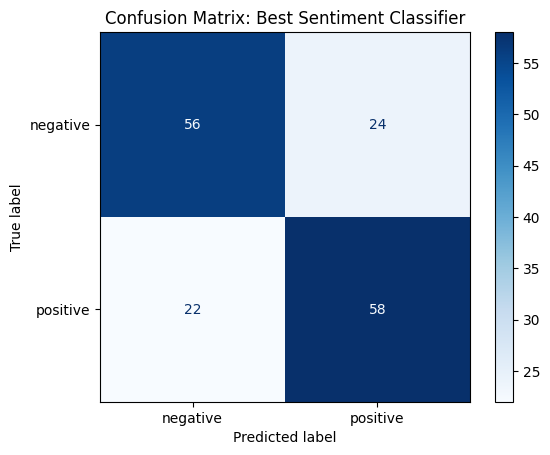

In [17]:
# ============================================================
# TASK 5.2: Confusion Matrix
# ============================================================

labels = ["negative", "positive"]

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    labels=labels,
    display_labels=labels,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix: Best Sentiment Classifier")
plt.grid(False)
plt.show()

## ANSWER: Task 5 — Model Evaluation

1. Accuracy ของ Best Model:

   `....................`

2. Precision ของ class `negative`:

   `....................`

3. Recall ของ class `negative`:

   `....................`

4. F1-score ของ class `negative`:

   `....................`

5. โมเดลทำนาย `negative` เป็น `positive` ผิดกี่ข้อความ:

   `....................`

6. โมเดลทำนาย `positive` เป็น `negative` ผิดกี่ข้อความ:

   `....................`

7. หากบริษัทต้องการตรวจสอบลูกค้าที่ไม่พอใจให้ครบมากที่สุด  
   ควรเน้น Precision หรือ Recall ของ class `negative` เพราะเหตุใด:

   `................................................................`

# Part 6: Error Analysis

การดู Accuracy เพียงอย่างเดียวไม่เพียงพอ

ในส่วนนี้ ให้วิเคราะห์ข้อความที่โมเดลทำนายผิดอย่างน้อย 3 ข้อความ
และพยายามอธิบายสาเหตุที่เป็นไปได้ เช่น:

- ข้อความสั้นเกินไป
- มีคำบวกและลบอยู่ในข้อความเดียวกัน
- มีคำปฏิเสธ เช่น ไม่, ไม่ได้, not
- มีการประชดประชัน
- ข้อมูลไม่มีบริบทเพียงพอ
- label เดิมอาจไม่ชัดเจน
- คำสำคัญไม่เคยปรากฏใน training set

In [18]:
# ============================================================
# TASK 6: Error Analysis
# ============================================================

error_df = pd.DataFrame({
    "review_text": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred_best
})

errors = error_df[
    error_df["actual"] != error_df["predicted"]
].copy()

print("Number of incorrect predictions:", len(errors))

display(errors.head(10))

Number of incorrect predictions: 46


,review_text,actual,predicted
1,แสงสีเขียวที่สร้างรอยยิ้ม เรียกเสียงหัวเราะ เพ...,negative,positive
3,ไม่รีบกลับอดน้ะ จุ้บๆ,positive,negative
13,อีกอย่างค่ะ พนักงานไม่ค่อยใส่ใจสนใจลูกค้าเท่าท...,negative,positive
15,ใช่ งงงกับคนจัดโป ใช้ไรคิด,negative,positive
16,เหอะๆ ไงล่ะ กษัตริย์ แสงโสม แบคเลส เบียร์ช้าง ...,negative,positive
18,mazda ออกแบบเลียนแบบ maserati,negative,positive
19,guerlain la petite robe noire lip color ink li...,positive,negative
25,บาบิก้อนหรือไรก็ได้จ้า,positive,negative
26,cab ของนาวาร่าราคาค่อนข้างสูงครับผมเองตอนแรกคิ...,negative,positive
29,จริง ยังเขย่าไม่เสร้จบอกหมด,negative,positive


## ANSWER: Task 6 — Error Analysis

เลือกข้อความที่โมเดลทำนายผิด 3 ข้อความจากตารางด้านบน

| ลำดับ | ข้อความ | Actual | Predicted | เหตุผลที่โมเดลอาจทำนายผิด |
|---:|---|---|---|---|
| 1 | ... | ... | ... | ... |
| 2 | ... | ... | ... | ... |
| 3 | ... | ... | ... | ... |

### สรุป Error Analysis

จากการวิเคราะห์ พบว่าโมเดลทำนายผิดบ่อยในกรณี:

`................................................................`

แนวทางปรับปรุงโมเดลหรือข้อมูล:

`................................................................`

# Part 7: Business Insight

สมมติว่าโมเดลนี้จะใช้ในระบบ customer support ของบริษัท

ให้สรุปผลจากการทดลองในมุมมองธุรกิจ
โดยใช้ข้อมูลจาก metrics, confusion matrix และ error analysis

## ANSWER: Task 7 — Business Insight

เขียนสรุปความยาว 8–10 บรรทัด

1. โมเดลมีประสิทธิภาพเพียงพอสำหรับใช้เป็น prototype หรือไม่ เพราะเหตุใด

   `................................................................`

2. บริษัทสามารถนำโมเดลนี้ไปใช้ใน workflow ใดได้บ้าง

   `................................................................`

3. หากต้องการตรวจพบข้อความเชิงลบให้มากขึ้น ควรปรับปรุงส่วนใด

   `................................................................`

4. ข้อจำกัดที่สำคัญของ TF-IDF + Logistic Regression คืออะไร

   `................................................................`

5. จาก Error Analysis บริษัทควรเก็บข้อมูลเพิ่มหรือปรับกระบวนการใด

   `................................................................`

# Challenge Activity

ทำเมื่อทำทุกส่วนหลักเสร็จแล้ว

เป้าหมาย: ดูว่าคำหรือวลีใดมีอิทธิพลต่อการทำนาย positive และ negative

In [19]:
# ============================================================
# CHALLENGE: Top Predictive Terms
# ============================================================

tfidf = best_model.named_steps["tfidf"]
classifier = best_model.named_steps["classifier"]

feature_names = tfidf.get_feature_names_out()
coefficients = classifier.coef_[0]

class_order = classifier.classes_

negative_class_index = list(class_order).index("negative")
positive_class_index = list(class_order).index("positive")

if len(class_order) != 2:
    raise ValueError("Challenge นี้รองรับเฉพาะ binary classification")

if positive_class_index == 1:
    top_positive_idx = np.argsort(coefficients)[-15:][::-1]
    top_negative_idx = np.argsort(coefficients)[:15]
else:
    top_positive_idx = np.argsort(coefficients)[:15]
    top_negative_idx = np.argsort(coefficients)[-15:][::-1]

print("Top terms associated with POSITIVE sentiment:")
print(feature_names[top_positive_idx])

print("\nTop terms associated with NEGATIVE sentiment:")
print(feature_names[top_negative_idx])

Top terms associated with POSITIVE sentiment:
['ขอบค' 'อยากก' 'แท' 'จะด' 'หน' 'อนส' 'honda' 'าาา' 'างคร' 'บพ' 'ดๆ'
 'อนเด' 'ไปก' 'เล' 'อยากก นอ']

Top terms associated with NEGATIVE sentiment:
['ไม' 'แต' 'งไม' 'แม' 'เห' 'เส' 'าอนาม' 'นไม' 'แล' 'งห' 'งก' 'สฟร'
 'นน สฟร' 'เซ' 'ได']


## ANSWER: Challenge

1. คำหรือวลีเชิงบวกที่โมเดลเรียนรู้:

   `................................................................`

2. คำหรือวลีเชิงลบที่โมเดลเรียนรู้:

   `................................................................`

3. คำเหล่านี้สอดคล้องกับความเข้าใจของมนุษย์หรือไม่ เพราะเหตุใด:

   `................................................................`

# Checklist ก่อนส่งงาน

- [ ] กรอกชื่อ รหัสนักศึกษา และกลุ่มแล้ว
- [ ] Upload dataset สำเร็จ
- [ ] รัน Data Exploration แล้ว
- [ ] สร้าง `clean_text` แล้ว
- [ ] แบ่ง Train/Test ด้วย `stratify=y` แล้ว
- [ ] รัน Experiment 1 และ Experiment 2 แล้ว
- [ ] เลือก Best Model แล้ว
- [ ] แสดง Classification Report แล้ว
- [ ] แสดง Confusion Matrix แล้ว
- [ ] วิเคราะห์ข้อความที่โมเดลทำนายผิด 3 ตัวอย่างแล้ว
- [ ] เขียน Business Insight แล้ว
- [ ] รัน `Runtime > Restart session and run all` แล้วไม่มี error
- [ ] เปลี่ยนชื่อไฟล์เป็น `student_id_text_mining_lab.ipynb`